In [4]:
import json

def print_json_structure(data, indent=0):
    """
    Recursively prints the keys of a JSON object to reveal its structure.
    """
    spacing = "  " * indent

    # If the current level is a dictionary, extract the keys
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{spacing}├── {key}")
            # Recurse deeper into the value
            print_json_structure(value, indent + 1)

    # If the current level is a list, show that it's a list and check the first item
    elif isinstance(data, list):
        if len(data) > 0:
            print(f"{spacing}├── [List / Array] -> showing structure of first item:")
            # Recurse into the first element to show what the list contains
            print_json_structure(data[0], indent + 1)
        else:
            print(f"{spacing}├── [Empty List]")

    # Base cases (strings, ints, floats, booleans, nulls) are ignored
    # as we only care about the structural fields (keys)

def analyze_json_file(file_path):
    """
    Loads a JSON file and triggers the structure analysis.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            data = json.load(file)
            print(f"Structure of {file_path}:\n")
            print_json_structure(data)
    except FileNotFoundError:
        print(f"Error: Could not find the file '{file_path}'.")
    except json.JSONDecodeError:
        print(f"Error: '{file_path}' does not contain valid JSON.")

# --- How to use it ---
if __name__ == "__main__":
    # Replace 'your_file.json' with the path to your actual JSON file
    rqtl_json_path = "../data/json_files/GCST90200330_GCST90200020.json"
    file_path=rqtl_json_path
    # Uncomment the line below to run it against your file
    # analyze_json_file(file_path)
    print_json_structure(file_path)

In [6]:
analyze_json_file(file_path)

Structure of ../data/json_files/GCST90200330_GCST90200020.json:

├── [List / Array] -> showing structure of first item:
  ├── ratio_accession
  ├── ratio_name
  ├── numerator_metabolite
    ├── name
    ├── hmdb
    ├── chebi
    ├── kegg
    ├── inchikey
    ├── accession
    ├── metabolon
  ├── denominator_metabolite
    ├── name
    ├── hmdb
    ├── chebi
    ├── kegg
    ├── inchikey
    ├── accession
    ├── metabolon
  ├── associated_regions
    ├── rs102275
      ├── summary_statistics
        ├── ratio_accession
        ├── pos_name
        ├── position
        ├── chromosome
        ├── effect_allele
        ├── reference_allele
        ├── maf
        ├── beta
        ├── se
        ├── z
        ├── log_pval
        ├── beta_1
        ├── se_1
        ├── z_1
        ├── beta_2
        ├── se_2
        ├── z_2
        ├── numerator_driven
        ├── denominator_driven
        ├── already_found
        ├── pgain
        ├── log_pgain
        ├── infomap_cluster
        ├── c

Academic figures generated successfully!


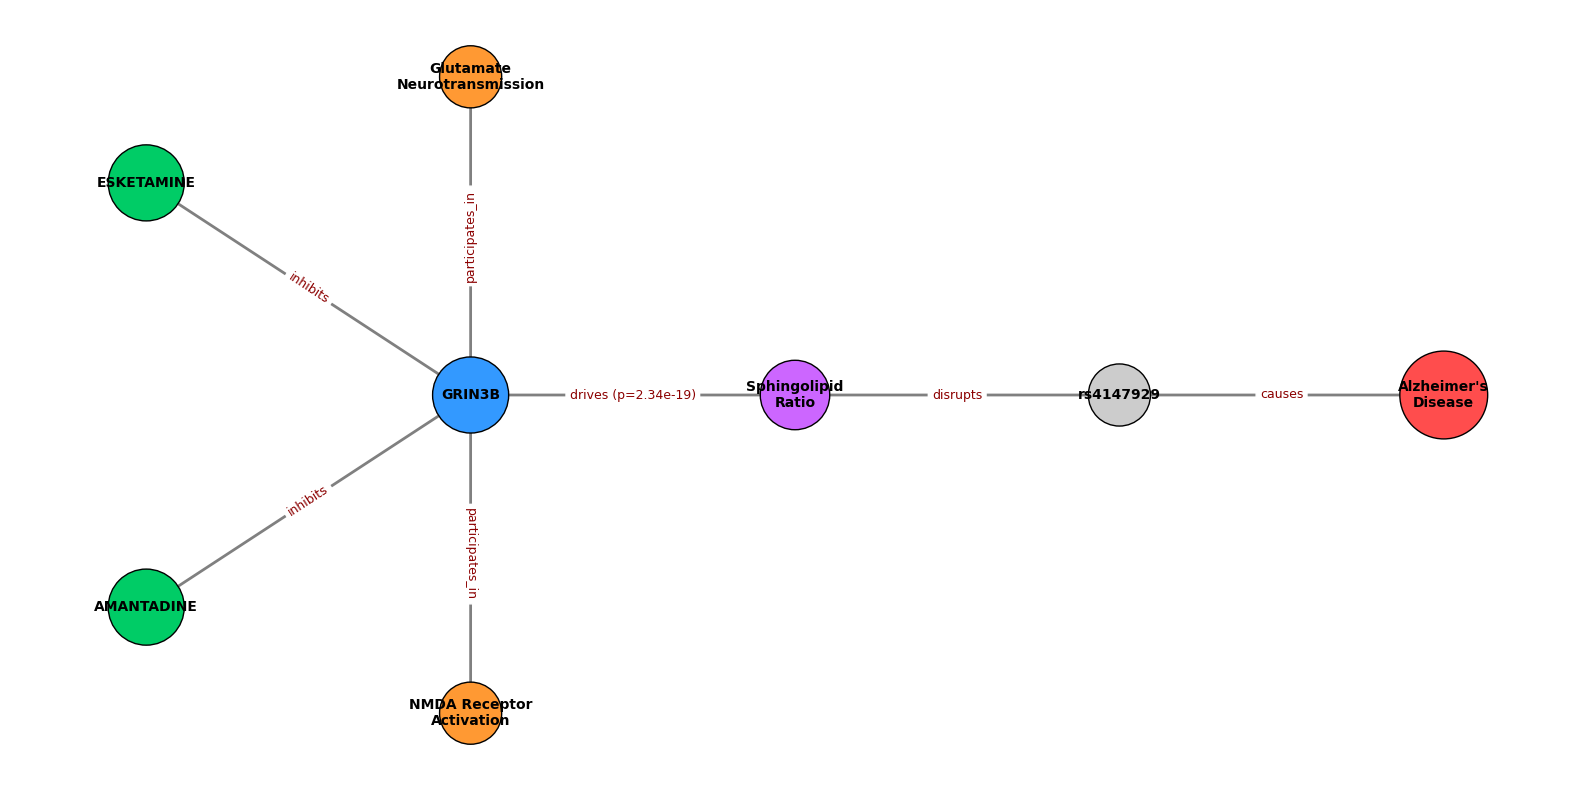

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize Graph
G = nx.DiGraph()

# 2. Add Nodes with properties
nodes = [
    ("Alzheimer's\nDisease", {"color": "#ff4d4d", "size": 4000}),
    ("rs4147929", {"color": "#cccccc", "size": 2000}),
    ("GRIN3B", {"color": "#3399ff", "size": 3000}),
    ("ESKETAMINE", {"color": "#00cc66", "size": 3000}),
    ("AMANTADINE", {"color": "#00cc66", "size": 3000}),
    ("Glutamate\nNeurotransmission", {"color": "#ff9933", "size": 2000}),
    ("NMDA Receptor\nActivation", {"color": "#ff9933", "size": 2000}),
    ("Sphingolipid\nRatio", {"color": "#cc66ff", "size": 2500})
]
for node, attrs in nodes:
    G.add_node(node, **attrs)

# 3. Add Edges with labels
edges = [
    ("rs4147929", "Alzheimer's\nDisease", "causes"),
    ("rs4147929", "Sphingolipid\nRatio", "disrupts"),
    ("GRIN3B", "Sphingolipid\nRatio", "drives (p=2.34e-19)"),
    ("GRIN3B", "Glutamate\nNeurotransmission", "participates_in"),
    ("GRIN3B", "NMDA Receptor\nActivation", "participates_in"),
    ("ESKETAMINE", "GRIN3B", "inhibits"),
    ("AMANTADINE", "GRIN3B", "inhibits")
]
for u, v, label in edges:
    G.add_edge(u, v, label=label)

# 4. Define manual layout for perfect academic flow (Left to Right)
pos = {
    "ESKETAMINE": (0, 1),
    "AMANTADINE": (0, -1),
    "GRIN3B": (2, 0),
    "Glutamate\nNeurotransmission": (2, 1.5),
    "NMDA Receptor\nActivation": (2, -1.5),
    "Sphingolipid\nRatio": (4, 0),
    "rs4147929": (6, 0),
    "Alzheimer's\nDisease": (8, 0)
}

# 5. Draw the Graph
fig, ax = plt.subplots(figsize=(16, 8))
colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]
sizes = [nx.get_node_attributes(G, 'size')[n] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, edgecolors="black", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=20, width=2, ax=ax)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="darkred", font_size=9, ax=ax)

ax.axis("off")
plt.tight_layout()

# 6. SAVE AS ACADEMIC FORMATS
# Save as 600 DPI High-Res PNG
plt.savefig("alzheimers_pathway.png", dpi=600, bbox_inches='tight')

# Save as Vector PDF (Best for Overleaf/LaTeX!)
plt.savefig("alzheimers_pathway.pdf", format="pdf", bbox_inches='tight')

print("Academic figures generated successfully!")

In [8]:
import pandas as pd
import glob
import os

# 1. Set the path to the folder containing your 10 CSVs
# Use a raw string (r"") for Windows paths or standard format for Mac/Linux
folder_path = r'../output/integration'
output_file = 'integration_report.xlsx'

# 2. Get a list of all CSV files in that folder
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

if not csv_files:
    print("No CSV files found in that directory.")
else:
    # 3. Create an Excel writer object
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        for file in csv_files:
            # Extract the file name to use as the sheet name
            sheet_name = os.path.splitext(os.path.basename(file))[0]

            # Read the CSV
            df = pd.read_csv(file)

            # Write to the Excel file (Excel limits sheet names to 31 chars)
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

    print(f"Successfully combined {len(csv_files)} files into {output_file}!")

Successfully combined 9 files into integration_report.xlsx!


In [2]:
pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)

   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ----------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pipreqs

  Using cached pipreqs-0.4.13-py2.py3-none-any.whl.metadata (7.4 kB)
  Using cached docopt-0.6.2.tar.gz (25 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached yarg-0.1.10-py2.py3-none-any.whl.metadata (4.5 kB)
Using cached pipreqs-0.4.13-py2.py3-none-any.whl (33 kB)
Using cached yarg-0.1.10-py2.py3-none-any.whl (13 kB)
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13887 sha256=a7e725ab6be0685e36afbe1235d1342178552fc8d43dc87da5c0c3df9e202125
  Stored in directory: c:\users\sadegh\appdata\local\pip\cache\wheels\79\6f\5f\26c3d1a144117ef52122d67c32b9f3c297c3dec4fea00a31ac
Successfully built docopt

   ---------------------------------------- 0/3 [docopt]
   ----------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
